In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Import the Dataset

In [2]:
path = Path("../data/raw/GermEval-2018-Data-master/germeval2018.training.txt")

text = path.read_text(encoding="utf-8")

print(text[:1000])

@corinnamilborn Liebe Corinna, wir würden dich gerne als Moderatorin für uns gewinnen! Wärst du begeisterbar?	OTHER	OTHER
@Martin28a Sie haben ja auch Recht. Unser Tweet war etwas missverständlich. Dass das BVerfG Sachleistungen nicht ausschließt, kritisieren wir.	OTHER	OTHER
@ahrens_theo fröhlicher gruß aus der schönsten stadt der welt theo ⚓️	OTHER	OTHER
@dushanwegner Amis hätten alles und jeden gewählt...nur Hillary wollten sie nicht und eine Fortsetzung von Obama-Politik erst recht nicht..!	OTHER	OTHER
@spdde kein verläßlicher Verhandlungspartner. Nachkarteln nach den Sondierzngsgesprächen - schickt diese Stümper #SPD in die Versenkung.	OFFENSE	INSULT
@Dirki_M Ja, aber wo widersprechen die Zahlen denn denen, die im von uns verlinkten Artikel stehen? In unserem Tweet geht es rein um subs. Geschützte. 2017 ist der gesamte Familiennachzug im Vergleich zu 2016 - die Zahlen, die Hr. Brandner bemüht - übrigens leicht rückläufig gewesen.	OTHER	OTHER
@milenahanm 33 bis 45 habe ich noch gar

In [3]:
lines = text.splitlines()

len(lines), lines [:5]

(5009,
 ['@corinnamilborn Liebe Corinna, wir würden dich gerne als Moderatorin für uns gewinnen! Wärst du begeisterbar?\tOTHER\tOTHER',
  '@Martin28a Sie haben ja auch Recht. Unser Tweet war etwas missverständlich. Dass das BVerfG Sachleistungen nicht ausschließt, kritisieren wir.\tOTHER\tOTHER',
  '@ahrens_theo fröhlicher gruß aus der schönsten stadt der welt theo ⚓️\tOTHER\tOTHER',
  '@dushanwegner Amis hätten alles und jeden gewählt...nur Hillary wollten sie nicht und eine Fortsetzung von Obama-Politik erst recht nicht..!\tOTHER\tOTHER',
  '@spdde kein verläßlicher Verhandlungspartner. Nachkarteln nach den Sondierzngsgesprächen - schickt diese Stümper #SPD in die Versenkung.\tOFFENSE\tINSULT'])

In [4]:
df = pd.read_csv(path, 
                 sep="\t",
                header=None,
                names=["comment", "label1", "label2"])

df.head()

,comment,label1,label2
0,"@corinnamilborn Liebe Corinna, wir würden dich...",OTHER,OTHER
1,@Martin28a Sie haben ja auch Recht. Unser Twee...,OTHER,OTHER
2,@ahrens_theo fröhlicher gruß aus der schönsten...,OTHER,OTHER
3,@dushanwegner Amis hätten alles und jeden gewä...,OTHER,OTHER
4,@spdde kein verläßlicher Verhandlungspartner. ...,OFFENSE,INSULT


## Merge the original splits into a single dataset for creating a custom train/validation/test split

In [5]:
test_path = Path("../data/raw/GermEval-2018-Data-master/germeval2018.test.txt")

test_df = pd.read_csv(
    test_path,
    sep="\t",
    header=None,
    names=["comment", "label1", "label2"],
    quoting=3,
    engine="python",
    on_bad_lines="warn"
)

test_df.head()

,comment,label1,label2
0,"Meine Mutter hat mir erzählt, dass mein Vater ...",OTHER,OTHER
1,@Tom174_ @davidbest95 Meine Reaktion; |LBR| Ni...,OTHER,OTHER
2,"#Merkel rollt dem Emir von #Katar, der islamis...",OTHER,OTHER
3,„Merle ist kein junges unschuldiges Mädchen“ K...,OTHER,OTHER
4,@umweltundaktiv Asylantenflut bringt eben nur ...,OFFENSE,ABUSE


In [6]:
df = pd.concat([df, test_df], ignore_index=True)

df.head()

,comment,label1,label2
0,"@corinnamilborn Liebe Corinna, wir würden dich...",OTHER,OTHER
1,@Martin28a Sie haben ja auch Recht. Unser Twee...,OTHER,OTHER
2,@ahrens_theo fröhlicher gruß aus der schönsten...,OTHER,OTHER
3,@dushanwegner Amis hätten alles und jeden gewä...,OTHER,OTHER
4,@spdde kein verläßlicher Verhandlungspartner. ...,OFFENSE,INSULT


## Exploring

In [7]:
df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 8541 entries, 0 to 8540
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   comment  8541 non-null   str  
 1   label1   8541 non-null   str  
 2   label2   8541 non-null   str  
dtypes: str(3)
memory usage: 1.4 MB


,comment,label1,label2
count,8541,8541,8541
unique,8541,2,4
top,"@corinnamilborn Liebe Corinna, wir würden dich...",OTHER,OTHER
freq,1,5651,5651


## Class Counts

In [8]:
df["label1"].value_counts()

label1
OTHER      5651
OFFENSE    2890
Name: count, dtype: int64

In [9]:
df["label2"].value_counts()

label2
OTHER        5651
ABUSE        1795
INSULT        976
PROFANITY     119
Name: count, dtype: int64

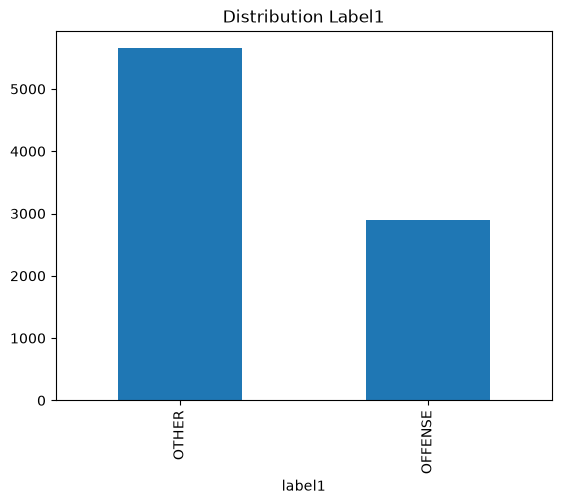

In [10]:
df["label1"].value_counts().plot.bar()
plt.title("Distribution Label1")
plt.show()

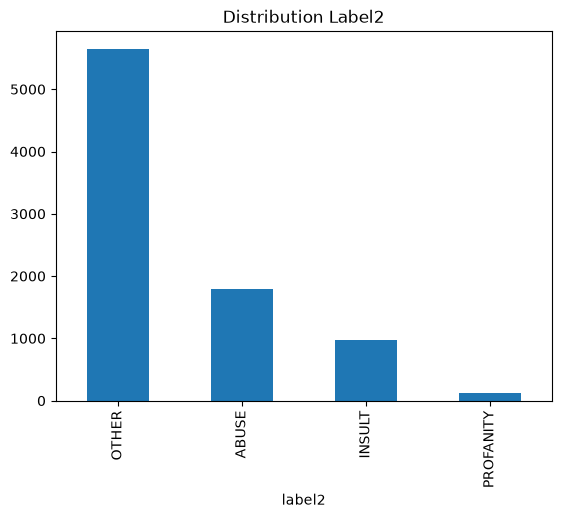

In [11]:
df["label2"].value_counts().plot.bar()
plt.title("Distribution Label2")
plt.show()

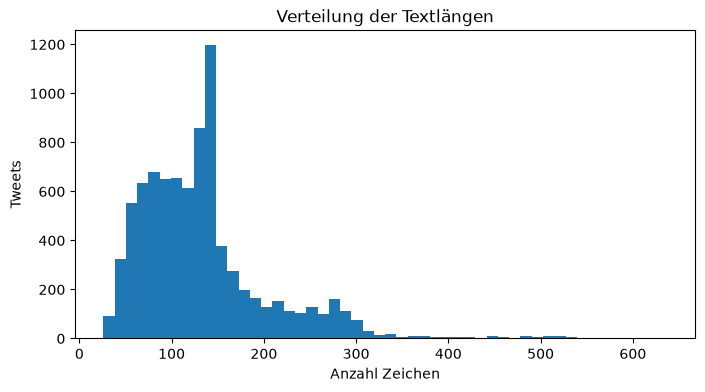

count    8541.000000
mean      134.032900
std        72.701373
min        26.000000
25%        85.000000
50%       125.000000
75%       152.000000
max       637.000000
Name: text_length, dtype: float64

In [12]:
# text length
df["text_length"] = df["comment"].str.len()

plt.figure(figsize=(8,4))
plt.hist(df["text_length"], bins=50)
plt.xlabel("Anzahl Zeichen")
plt.ylabel("Tweets")
plt.title("Verteilung der Textlängen")
plt.show()

df["text_length"].describe()

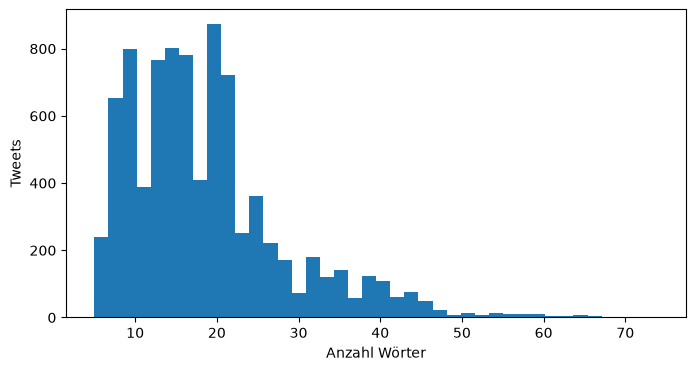

In [14]:
df["num_words"] = df["comment"].str.split().str.len()

df["num_words"].describe()

plt.figure(figsize=(8,4))
plt.hist(df["num_words"], bins=40)
plt.xlabel("Anzahl Wörter")
plt.ylabel("Tweets")
plt.show()

## Are the Comments diffrent in length given the Class?

In [15]:
df.groupby("label1")["num_words"].mean()

label1
OFFENSE    18.312803
OTHER      18.916475
Name: num_words, dtype: float64

In [16]:
df.groupby("label1")["text_length"].mean()

label1
OFFENSE    130.235640
OTHER      135.974872
Name: text_length, dtype: float64